In [366]:
#Bibliotecas
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [367]:
caminho_arquivo = "tratados_3det/iron/iron3.16E15"

def processar_arquivo(nome_arquivo):
    # Listas para armazenar as detecções por tipo de partícula e por detector
    positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    electrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_plus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para totais por detector
    total_por_detector = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para somas de elétrons+pósitrons e múons+/-
    soma_electrons_positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    soma_muons_plus_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Abrir e ler o arquivo
    with open(nome_arquivo, 'r') as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            # Processar apenas linhas que começam com TRIG
            if linha.startswith("TRIG"):
                partes = linha.split()
                detector = partes[0]  # TRIG1, TRIG2, TRIG3

                # Valores das partículas
                pos = int(partes[1])  # Pósitrons
                ele = int(partes[2])  # Elétrons
                mu_p = int(partes[3])  # Múons+
                mu_m = int(partes[4])  # Múons-

                # Adicionar os valores às listas correspondentes
                positrons[detector].append(pos)
                electrons[detector].append(ele)
                muons_plus[detector].append(mu_p)
                muons_minus[detector].append(mu_m)

                # Calcular totais
                total = pos + ele + mu_p + mu_m
                total_por_detector[detector].append(total)

                # Calcular somas
                soma_electrons_positrons[detector].append(pos + ele)
                soma_muons_plus_minus[detector].append(mu_p + mu_m)

    # Retornar os dados processados
    return {
        "positrons": positrons,
        "electrons": electrons,
        "muons_plus": muons_plus,
        "muons_minus": muons_minus,
        "total_por_detector": total_por_detector,
        "soma_electrons_positrons": soma_electrons_positrons,
        "soma_muons_plus_minus": soma_muons_plus_minus
    }

# Função principal
def main():
    
    dados = processar_arquivo(caminho_arquivo)

    # Alguns testes
    print("Detecções de pósitrons no TRIG1:", dados["positrons"]["TRIG1"])
    print("Total de partículas no TRIG2:", dados["total_por_detector"]["TRIG2"])
    print("Soma de elétrons e pósitrons no TRIG3:", dados["soma_electrons_positrons"]["TRIG3"])

    return dados



# Executar o programa
if __name__ == "__main__":
    dados_processados = main()


Detecções de pósitrons no TRIG1: [0, 0, 1, 5, 16, 1, 2, 20, 2, 0, 2, 6, 34, 0, 11, 0, 1, 0, 16, 22, 8, 0, 6, 12, 1, 1, 0, 27, 0, 3, 0, 2, 0, 20, 0, 14, 1, 0, 2, 28, 21, 23, 2, 23, 17, 31, 32, 0, 1, 14, 40, 0, 0, 2, 6, 5, 3, 14, 12, 7, 1, 2, 6, 12, 0, 0, 0, 4, 56, 0, 30, 10, 0, 0, 5, 14, 24, 31, 0, 0, 16, 17, 23, 24, 10, 0, 2, 1, 13, 2, 49, 1, 1, 8, 4, 34, 1, 8, 18, 0, 0, 2, 0, 15, 7, 9, 27, 0, 4, 0, 0, 29, 16, 15, 24, 1, 0, 2, 1, 2, 15, 2, 1, 0, 22, 60, 49, 4, 3, 37, 32, 11, 0, 5, 0, 0, 17, 5, 1, 0, 42, 0, 0, 2, 0, 23, 10, 7, 9, 14, 11, 2, 0, 22, 0, 0, 18, 8, 48, 3, 25, 0, 27, 0, 14, 1, 11, 1, 19, 9, 1, 3, 1, 27, 1, 20, 51, 2, 1, 0, 0, 0, 38, 7, 0, 6, 2, 18, 2, 1, 17, 11, 23, 9, 6, 26, 0, 2, 1, 14, 1, 15, 0, 12, 2, 3, 26, 14, 4, 0, 10, 21, 2, 0, 0, 0, 21, 18, 0, 19, 27, 7, 7, 6, 3, 0, 34, 0, 0, 3, 0, 0, 32, 0, 26, 2, 27, 28, 19, 29, 0, 0, 1, 27, 3, 16, 31, 0, 43, 12, 6, 0, 0, 0, 0, 0, 1, 2, 13, 48, 0, 0, 0, 60, 0, 3, 2, 37, 2, 1, 4, 40, 14, 41, 0, 0, 0, 23, 12, 6, 6, 14, 3, 4, 8, 0, 0,

In [368]:
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Iron 3.16E15'

In [369]:
# Posição dos tanques
x1 = [0, 800/np.sqrt(3)]
x2 = [-400, -400/np.sqrt(3)]
x3 = [400, -400/np.sqrt(3)]

# Distância dos tanques em relação ao centro
r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5


# Total de partículas em cada tanque
trig1_total = dados_processados['total_por_detector']['TRIG1']
trig2_total = dados_processados['total_por_detector']['TRIG2']
trig3_total = dados_processados['total_por_detector']['TRIG3']

print(trig1_total,'\n',
      trig2_total,'\n',
      trig3_total)

[0, 0, 2, 20, 43, 10, 2, 44, 5, 2, 6, 23, 63, 1, 31, 1, 2, 2, 56, 56, 27, 0, 19, 28, 3, 2, 3, 69, 1, 16, 0, 6, 0, 57, 0, 24, 6, 1, 10, 60, 54, 41, 6, 59, 51, 93, 78, 0, 3, 39, 91, 0, 3, 8, 13, 19, 8, 23, 37, 25, 5, 9, 17, 27, 0, 1, 0, 12, 121, 0, 70, 21, 2, 1, 10, 31, 58, 71, 0, 2, 61, 33, 59, 57, 26, 0, 3, 4, 28, 3, 119, 7, 3, 21, 13, 81, 1, 31, 60, 0, 4, 3, 0, 40, 17, 18, 52, 1, 8, 0, 2, 68, 38, 40, 58, 3, 0, 3, 2, 23, 27, 7, 3, 0, 44, 152, 113, 9, 11, 88, 71, 29, 0, 10, 0, 1, 29, 12, 1, 1, 100, 0, 1, 9, 0, 53, 22, 21, 20, 33, 22, 7, 0, 77, 0, 0, 36, 16, 99, 8, 51, 0, 58, 1, 26, 2, 34, 3, 47, 20, 7, 8, 2, 84, 3, 37, 138, 3, 4, 2, 1, 0, 108, 23, 0, 13, 4, 40, 6, 1, 44, 22, 48, 16, 13, 81, 1, 7, 8, 27, 2, 34, 0, 43, 7, 18, 59, 38, 8, 0, 21, 45, 7, 0, 0, 6, 46, 35, 0, 55, 86, 19, 12, 11, 10, 0, 87, 2, 1, 10, 3, 0, 77, 8, 62, 8, 68, 58, 41, 84, 0, 1, 4, 65, 6, 47, 71, 1, 105, 29, 19, 0, 0, 2, 0, 1, 1, 5, 25, 108, 0, 0, 0, 119, 0, 6, 5, 94, 18, 1, 15, 97, 47, 111, 0, 0, 0, 50, 21, 19, 8, 

In [370]:
# Triangulação

triangulacao = [
    (a, b, c) for a, b, c in zip(trig1_total, trig2_total, trig3_total) if a != 0 and b != 0 and c != 0
]

trig1, trig2, trig3 = zip(*triangulacao) if triangulacao else ([], [], [])


print(trig1,'\n',
      trig2,'\n',
      trig3)

(2, 20, 43, 10, 44, 5, 6, 23, 63, 31, 56, 56, 27, 19, 28, 3, 3, 69, 16, 6, 57, 24, 6, 10, 60, 54, 41, 6, 59, 51, 93, 78, 3, 39, 91, 3, 13, 19, 8, 23, 37, 25, 5, 9, 17, 27, 12, 121, 70, 21, 10, 31, 58, 71, 2, 61, 33, 59, 57, 26, 3, 4, 28, 3, 119, 7, 3, 21, 13, 81, 1, 31, 60, 40, 17, 18, 52, 8, 68, 38, 40, 58, 3, 3, 23, 27, 7, 44, 152, 113, 9, 11, 88, 71, 29, 10, 29, 12, 1, 100, 1, 9, 53, 22, 21, 20, 33, 22, 7, 77, 36, 16, 99, 8, 51, 58, 1, 26, 2, 34, 47, 20, 7, 8, 2, 84, 37, 138, 2, 108, 23, 13, 4, 40, 6, 1, 44, 22, 48, 16, 13, 81, 1, 7, 8, 27, 2, 34, 43, 7, 18, 59, 38, 8, 21, 45, 7, 6, 46, 35, 55, 86, 19, 12, 11, 10, 87, 2, 1, 10, 3, 77, 8, 62, 8, 68, 58, 41, 84, 1, 4, 65, 6, 47, 71, 1, 105, 29, 19, 2, 1, 25, 108, 119, 6, 5, 94, 18, 1, 15, 97, 47, 111, 50, 21, 19, 8, 37, 7, 9, 20, 53, 92, 14, 12, 48, 5, 1, 4, 38, 40, 76, 12, 6, 92, 3, 1, 3, 53, 11, 32) 
 (2, 32, 53, 4, 41, 12, 1, 13, 47, 34, 71, 47, 27, 20, 44, 8, 9, 58, 15, 8, 53, 31, 3, 8, 62, 78, 44, 12, 60, 77, 115, 77, 8, 31, 89, 

In [371]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [372]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data, strict=False)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)

df

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,2,2,2,0.0,0.000151,0.000151,0.000151,461.880215,461.880215,461.880215
-14.814815,-59.873361,20,32,29,61.678993,0.001507,0.002411,0.002185,521.963862,421.463472,448.703869
40.963855,-51.474602,43,53,70,65.785045,0.00324,0.003993,0.005274,514.986608,476.085065,401.391107
40.0,115.470054,10,4,6,122.202019,0.000753,0.000301,0.000452,348.711915,560.0,499.59984
59.459459,-24.966498,44,41,63,64.488397,0.003315,0.003089,0.004746,490.464219,503.515762,397.986165
…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,1,1,1,0.0,0.000075,0.000075,0.000075,461.880215,461.880215,461.880215
33.333333,-57.735027,3,4,5,66.666667,0.000226,0.000301,0.000377,520.683312,466.666667,405.517502
35.39823,94.011017,53,25,35,100.454497,0.003993,0.001883,0.002637,369.568372,543.290762,488.392961


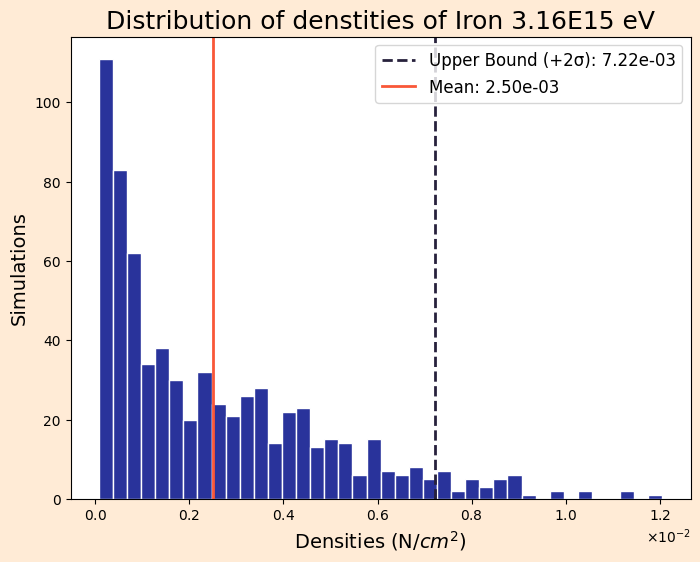

In [373]:
from matplotlib.ticker import ScalarFormatter

values = df.select(['rho1', 'rho2', 'rho3']).to_numpy().flatten()

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.ylabel('Simulations')
plt.xlabel('Densities (N/$cm^2$)')  
plt.title('Distribution of denstities of ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$cm^2$)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

In [374]:
#def calcular_s(rho_i, rho_j, r_i, r_j):
#    log_rho_diff = pl.col(rho_i).log() - pl.col(rho_j).log()
#    log_r_diff = pl.col(r_i).abs().log() - pl.col(r_j).abs().log()
#
#    s_expr = pl.when((log_rho_diff == 0) & (log_r_diff == 0)) \
#              .then(0) \
#              .otherwise(-log_rho_diff / log_r_diff)
#    
#    return s_expr
#
#df = df.with_columns([
#    calcular_s("rho1", "rho2", "r1_b", "r2_b").alias("s1"),
#    calcular_s("rho2", "rho3", "r2_b", "r3_b").alias("s2"),
#    calcular_s("rho1", "rho3", "r1_b", "r3_b").alias("s3"),
#])
#
#df = df.with_columns(
#    df.select(["s1", "s2", "s3"]).mean_horizontal().alias("s_mean")
#)
#df

In [375]:
#r0 = 7800
#
## Função para o ajuste
#def model(r, C, s, r0):
#    return C * ((r/r0)**s) / (r0**2)
#
## Função para ajustar e encontrar C
#def find_C(row):
#    
#    rho_values = np.array([row["rho1"], row["rho2"], row["rho3"]])
#    r_values = np.array([row["r1_b"], row["r2_b"], row["r3_b"]])
#    s = row["s_mean"]
#    
#    popt, _ = curve_fit(
#        lambda r, C, s: model(r, C, s, r0),  
#        r_values,                          
#        rho_values,                        
#        p0=[800.0, -1],
#        bounds= ([800, -2], [np.inf, 2])   
#    )
#    
#    return popt[0]
#
#df = df.with_columns(
#    pl.struct(["rho1", "rho2", "rho3", "r1_b", "r2_b", "r3_b", "s_mean"])
#    .map_elements(lambda row: find_C(row), return_dtype= float)
#    .alias("C_optimized")
#)
#
#df = df.with_columns([
#    (pl.col("rho1") * r0**2 * pl.col("r1_b")**pl.col("s_mean")).alias("C1"),
#    (pl.col("rho2") * r0**2 * pl.col("r2_b")**pl.col("s_mean")).alias("C2"),
#    (pl.col("rho3") * r0**2 * pl.col("r3_b")**pl.col("s_mean")).alias("C3")
#])
#
#df = df.with_columns(
#    ((pl.col("C1") + pl.col("C2") + pl.col("C3")) / 3).alias("C_mean")
#)
#
#df

In [376]:
# Modelagem NKG
#def model(r, C, s):
#    r0 = 7800
#    return C/(r0**2)*(r/r0)**(s-2)*(1+r/r0)**(s-4.5)

def model(r, C, s, r0=7800):
     return C/(r0**2) * (r/r0)**(s)

parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = ['r1_b', 'r2_b', 'r3_b']  
y_cols = ['rho1', 'rho2', 'rho3']

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i]  
    rho = y[i]  
    try:
        popt, pcov = curve_fit(model, r, rho, p0= [2E4, -0.5] , bounds= ([0, -1], [np.inf, 2]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append(popt)
        uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    's': [p[1] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    's_err': [e[1] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {parameters_df['C'].mean():.2e} ± {parameters_df['C'].std():.2e}")
print(f"s: Média = {parameters_df['s'].mean():.2f} ± {parameters_df['s'].std():.2f}")

shape: (231, 6)
┌──────────────┬───────────┬──────────────┬──────────────┬──────────┬───────────┐
│ C            ┆ s         ┆ C_err        ┆ s_err        ┆ R_2      ┆ RMSE      │
│ ---          ┆ ---       ┆ ---          ┆ ---          ┆ ---      ┆ ---       │
│ f64          ┆ f64       ┆ f64          ┆ f64          ┆ f64      ┆ f64       │
╞══════════════╪═══════════╪══════════════╪══════════════╪══════════╪═══════════╡
│ 14670.834517 ┆ 0.166146  ┆ 4.3224e9     ┆ 104234.10314 ┆ NaN      ┆ 8.9379e-8 │
│ 7129.636575  ┆ -0.999818 ┆ 25900.091636 ┆ 1.277967     ┆ 0.682378 ┆ 0.000217  │
│ 14423.182745 ┆ -0.999805 ┆ 41998.903655 ┆ 1.021253     ┆ 0.724552 ┆ 0.000441  │
│ 2956.503678  ┆ -0.830184 ┆ 7881.078231  ┆ 0.916365     ┆ 0.71304  ┆ 0.000101  │
│ 13459.555009 ┆ -0.99535  ┆ 31037.043852 ┆ 0.808289     ┆ 0.79389  ┆ 0.000333  │
│ …            ┆ …         ┆ …            ┆ …            ┆ …        ┆ …         │
│ 13085.276389 ┆ 0.36434   ┆ 1.2569e11    ┆ 3.3983e6     ┆ NaN      ┆ 0.000001  │


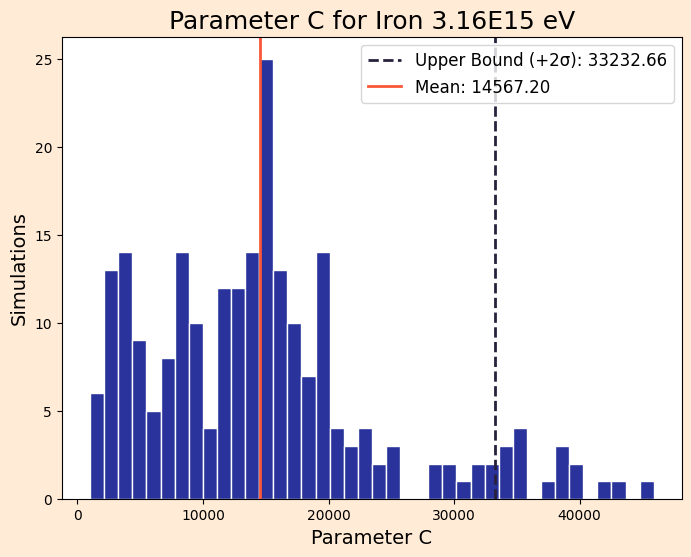

In [377]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

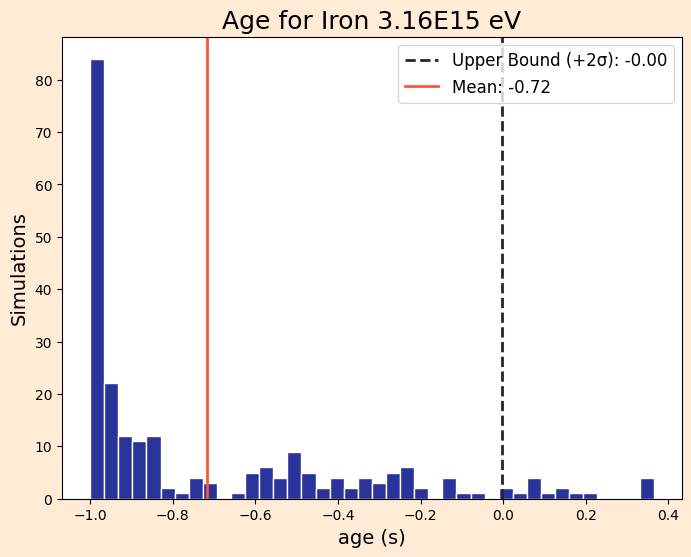

In [378]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['s'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('s')
plt.title('Age for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['s'].mean()
std = parameters_df['s'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('age (s)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/age_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

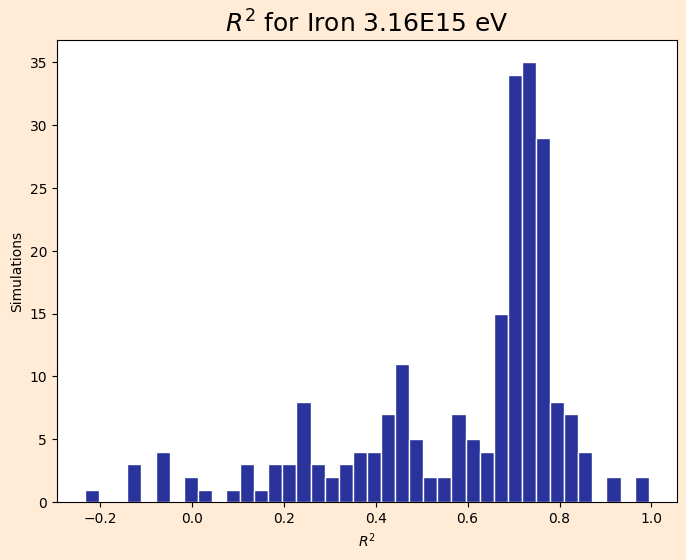

In [379]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

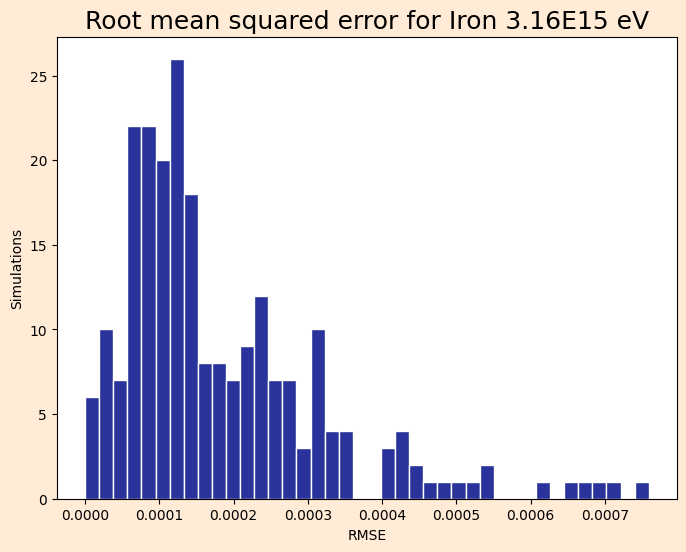

In [380]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

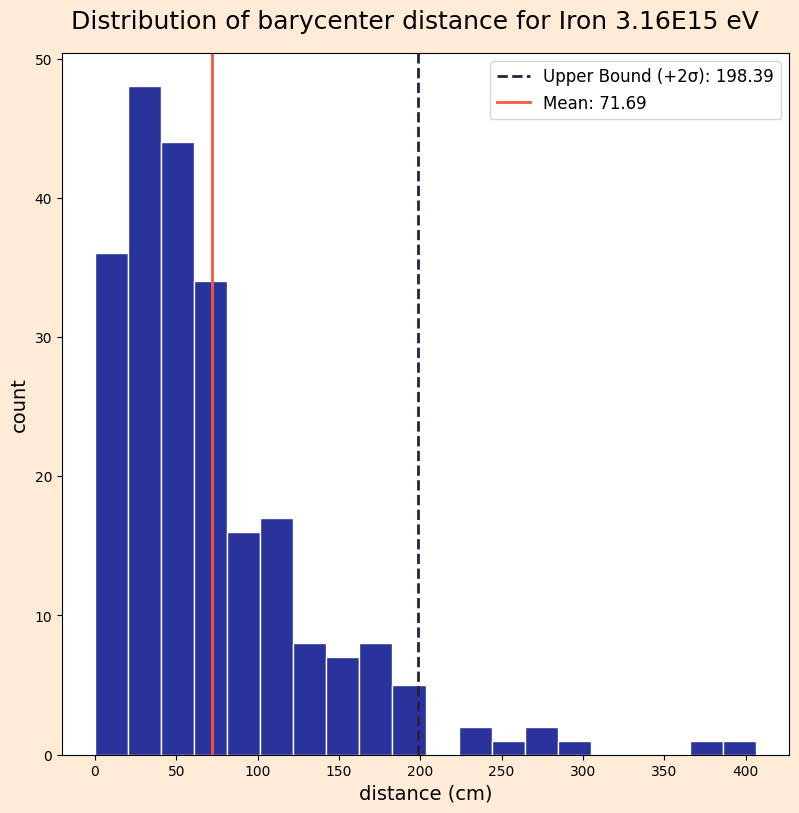

In [381]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 20)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('count', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

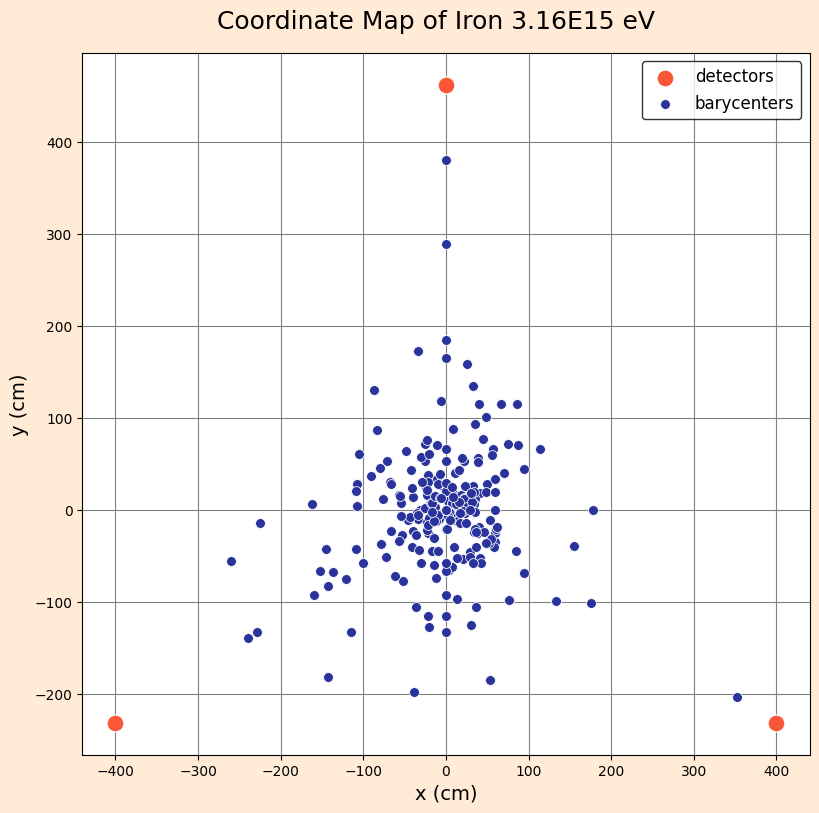

In [382]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#29339B',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/map_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

In [383]:
# Plot dos tanques
#fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
#fig.suptitle('Coordinate Map of Detectors', size = 18)
#fig.tight_layout()
#ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')
#
#sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
#
#ax.set_xlabel('x (cm)', size = 14)
#ax.set_ylabel('y (cm)', size = 14)
#
#
#ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

[7.72879490e-18 5.80966465e-03]
[2.66092648 3.34151029 4.02294651 4.70353032]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\762320414.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\762320414.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.665112,14.0,14.003073,0.021949
3.33385,14.499687,14.494063,0.038788
4.025715,15.0,15.002033,0.013553
4.704236,15.499687,15.500205,0.003344


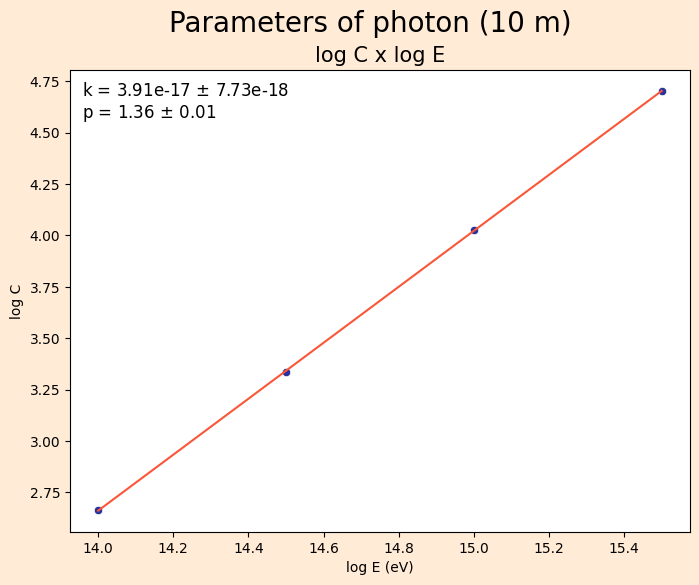

In [384]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [462.5, 2157, 1.061e+04, 5.061e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df_photon = pl.DataFrame(data)

df_photon = df_photon.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df_photon

In [385]:
k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = parameters_df['C'] 
#c_photon = df['C_optimized']
E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
1.2746e15,59.665448,1.8854e15
7.5037e14,76.254186,2.4096e15
1.2587e15,60.166475,1.9013e15
3.9318e14,87.557458,2.7668e15
1.1964e15,62.138282,1.9636e15
…,…,…
1.1719e15,62.914176,1.9881e15
1.2304e15,61.062116,1.9296e15
9.8166e14,68.934722,2.1783e15


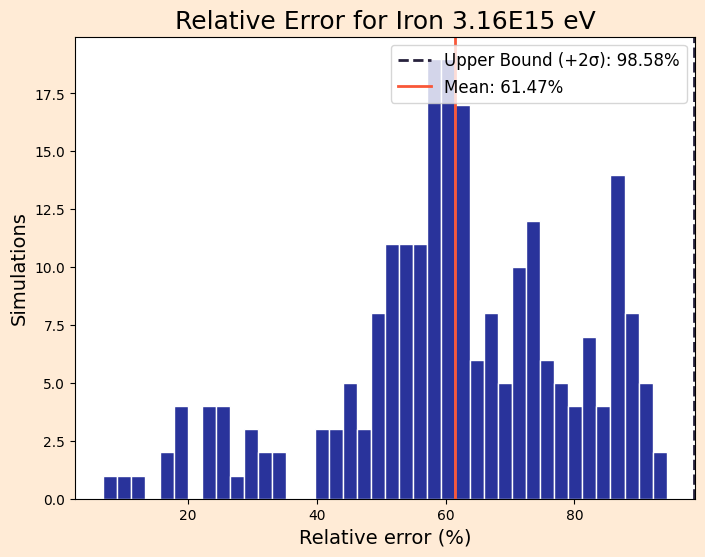

In [386]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[1.29082114e-08 1.02286966e-01]
[2.93312376 3.33870508 3.74479438 4.1503757 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2154559052.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2154559052.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.876507,14.0,13.930246,0.498243
3.464936,14.499687,14.655207,1.072578
3.662096,15.0,14.898114,0.67924
4.16346,15.499687,15.515807,0.104


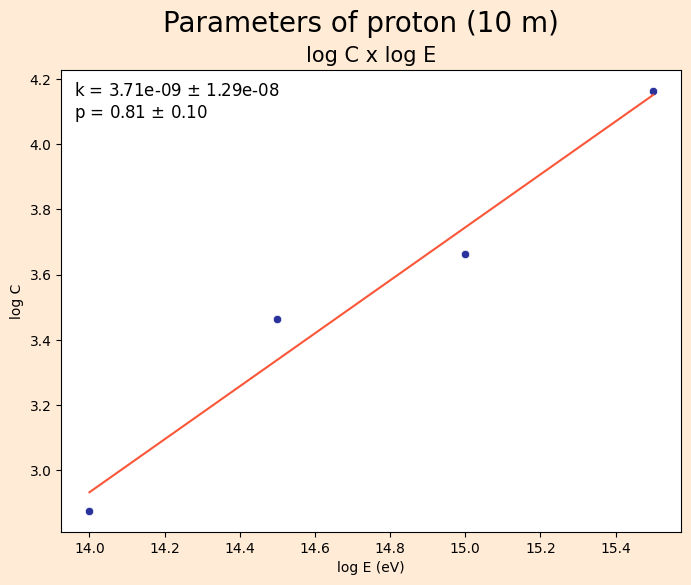

In [387]:
# Fit do próton
from scipy.optimize import curve_fit

C = [752.5, 2917, 4593, 1.457e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [388]:
k_proton = coefficients_proton[0] 
p_proton = coefficients_proton[1] 
c_proton = parameters_df['C'] 
#c_photon = df['C_optimized']
E_proton = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_proton)):
    E = (c_proton[i] / k_proton) ** (1 / p_proton)
    E_proton.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_proton,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
3.3075e15,4.66703,1.4748e14
1.3596e15,56.976258,1.8004e15
3.2388e15,2.494521,7.8827e13
4.5963e14,85.45486,2.7004e15
2.9743e15,5.875564,1.8567e14
…,…,…
2.8728e15,9.089768,2.8724e14
3.1176e15,1.343069,4.2441e13
2.1340e15,32.466971,1.0260e15


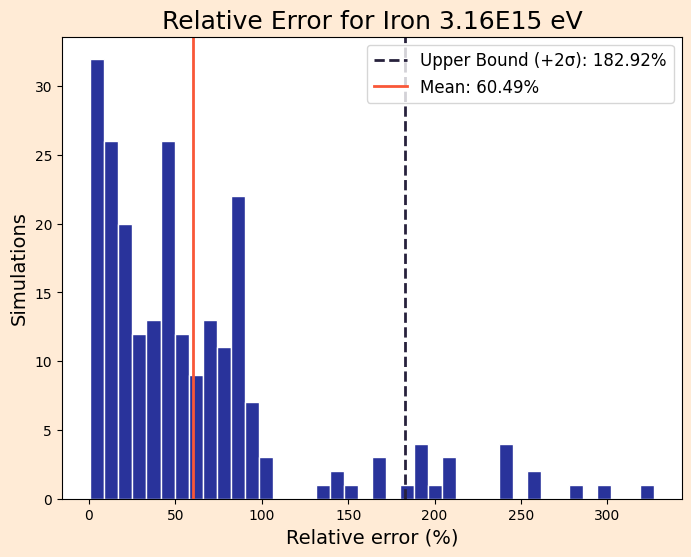

In [389]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[3.49020900e-13 2.98935993e-01]
[2.55625971 3.12805531 3.70056706 4.27236266]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2562053064.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2562053064.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.596377,14.0,14.035058,0.250416
3.265054,14.499687,14.619409,0.825685
3.305996,15.0,14.655188,2.298748
4.489818,15.499687,15.689719,1.226039


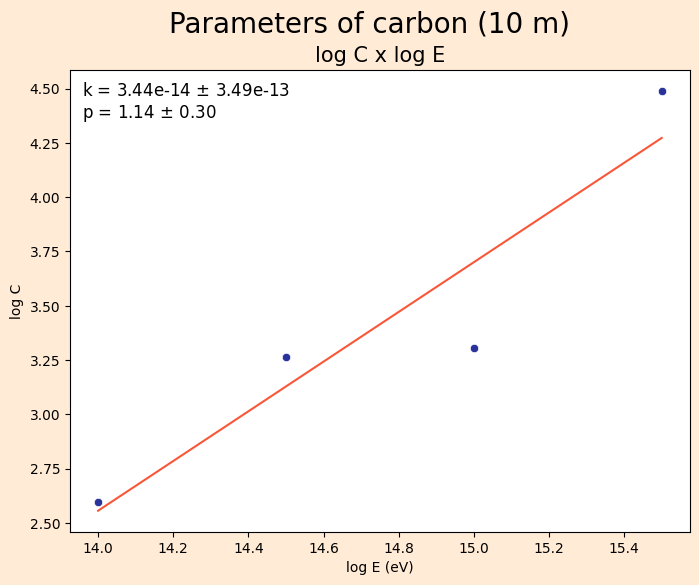

In [390]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [394.8, 1841, 2023, 3.089e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [391]:
k_carbon = coefficients_carbon[0] 
p_carbon = coefficients_carbon[1] 
c_carbon = parameters_df['C'] 
#c_photon = df['C_optimized']
E_carbon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_carbon)):
    E = (c_carbon[i] / k_carbon) ** (1 / p_carbon)
    E_carbon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_carbon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
2.5535e15,19.193167,6.0650e14
1.3592e15,56.988796,1.8008e15
2.5158e15,20.386488,6.4421e14
6.2978e14,80.070212,2.5302e15
2.3683e15,25.054859,7.9173e14
…,…,…
2.3106e15,26.879317,8.4939e14
2.4486e15,22.512557,7.1140e14
1.8714e15,40.779707,1.2886e15


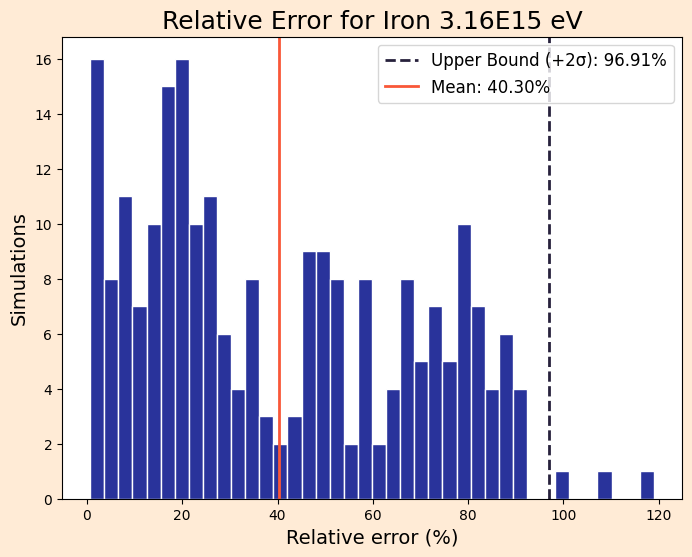

In [392]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[2.13531837e-17 3.72073539e-02]
[2.45042069 3.13652323 3.82348508 4.50958763]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2199846615.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2199846615.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.426674,14.0,13.982705,0.123534
3.184407,14.499687,14.534561,0.240516
3.798927,15.0,14.982114,0.119239
4.510009,15.499687,15.499994,0.001978


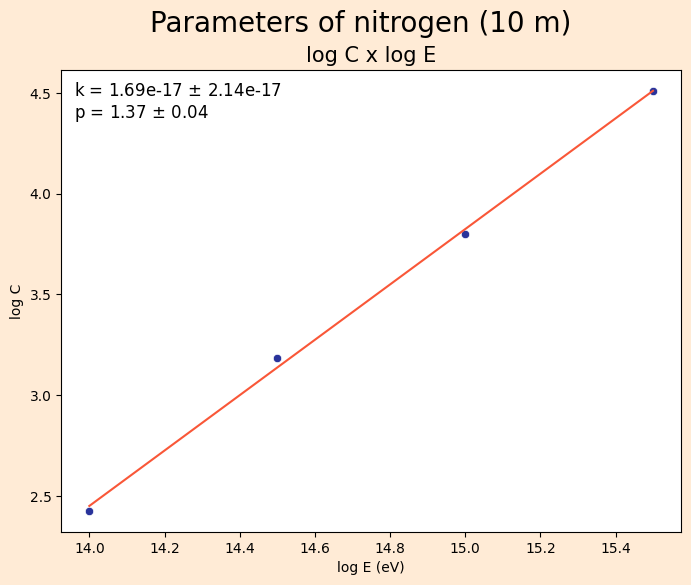

In [393]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [267.1, 1529, 6294, 3.236e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [394]:
k_nitrogen = coefficients_nitrogen[0] 
p_nitrogen = coefficients_nitrogen[1] 
c_nitrogen = parameters_df['C'] 
#c_photon = df['C_optimized']
E_nitrogen = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_nitrogen)):
    E = (c_nitrogen[i] / k_nitrogen) ** (1 / p_nitrogen)
    E_nitrogen.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_nitrogen,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
1.7774e15,43.753296,1.3826e15
1.0509e15,66.744946,2.1091e15
1.7555e15,44.446394,1.4045e15
5.5351e14,82.483902,2.6065e15
1.6693e15,47.174798,1.4907e15
…,…,…
1.6353e15,48.248717,1.5247e15
1.7163e15,45.685562,1.4437e15
1.3718e15,56.588255,1.7882e15


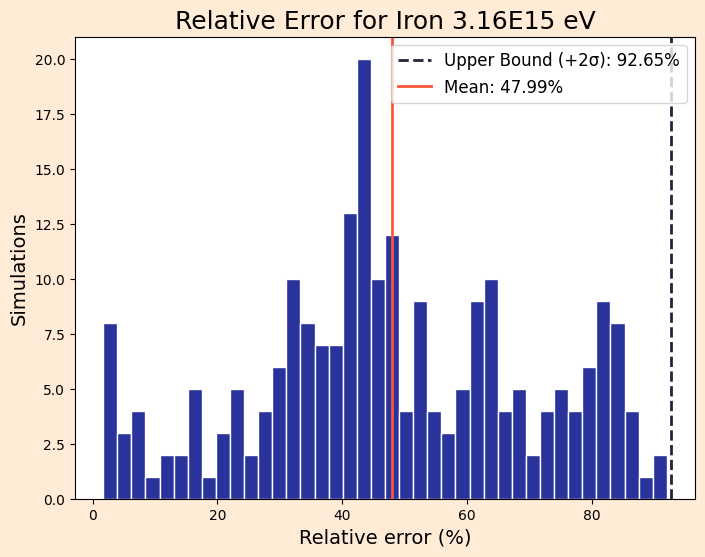

In [395]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[3.02197621e-16 4.02972366e-02]
[2.48824207 3.1358558  3.78428063 4.43189435]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2364096372.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\2364096372.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.460597,14.0,13.97867,0.152359
3.156852,14.499687,14.515887,0.111728
3.825231,15.0,15.031597,0.210645
4.397592,15.499687,15.47322,0.170757


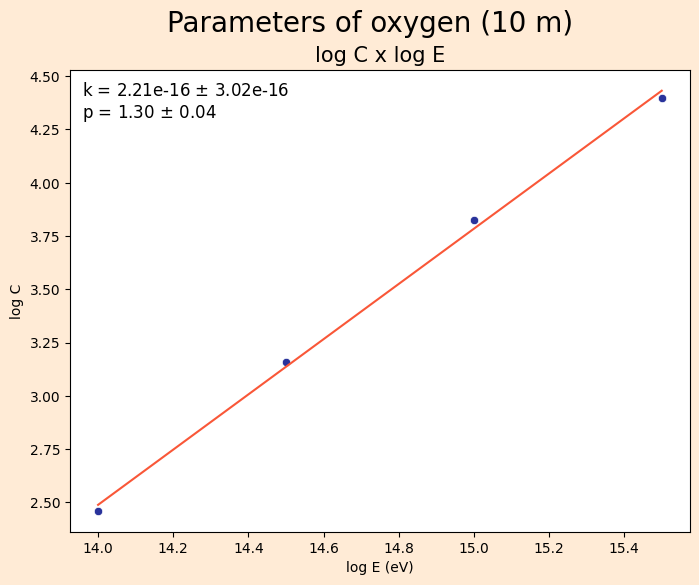

In [396]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [288.8, 1435, 6687, 2.498e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [397]:
k_oxygen = coefficients_oxygen[0] 
p_oxygen = coefficients_oxygen[1] 
c_oxygen = parameters_df['C'] 
#c_photon = df['C_optimized']
E_oxygen = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_oxygen)):
    E = (c_oxygen[i] / k_oxygen) ** (1 / p_oxygen)
    E_oxygen.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_oxygen,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
1.9719e15,37.598987,1.1881e15
1.1300e15,64.24082,2.0300e15
1.9461e15,38.413322,1.2139e15
5.7294e14,81.869062,2.5871e15
1.8450e15,41.61304,1.3150e15
…,…,…
1.8053e15,42.869808,1.3547e15
1.9002e15,39.867734,1.2598e15
1.4987e15,52.574018,1.6613e15


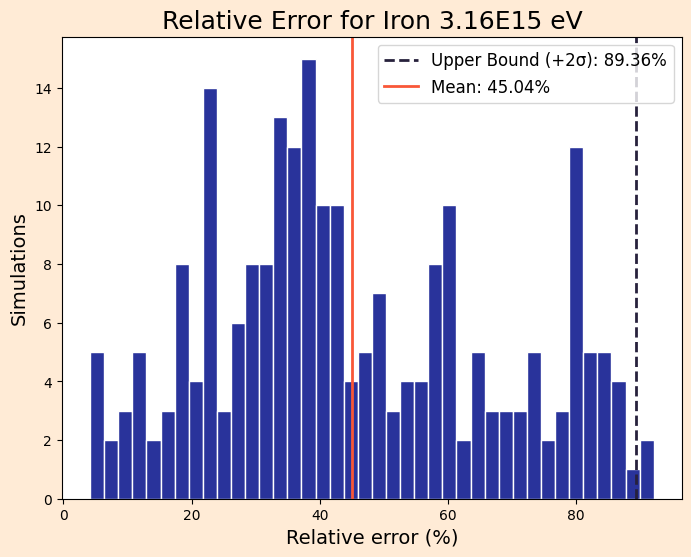

In [398]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[5.31366099e-17 2.07479286e-02]
[2.33311074 2.99184131 3.65139691 4.31012748]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\1172844773.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_14180\1172844773.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.340642,14.0,14.005713,0.040809
2.969649,14.499687,14.482853,0.116101
3.673205,15.0,15.016543,0.110286
4.30298,15.499687,15.494265,0.03498


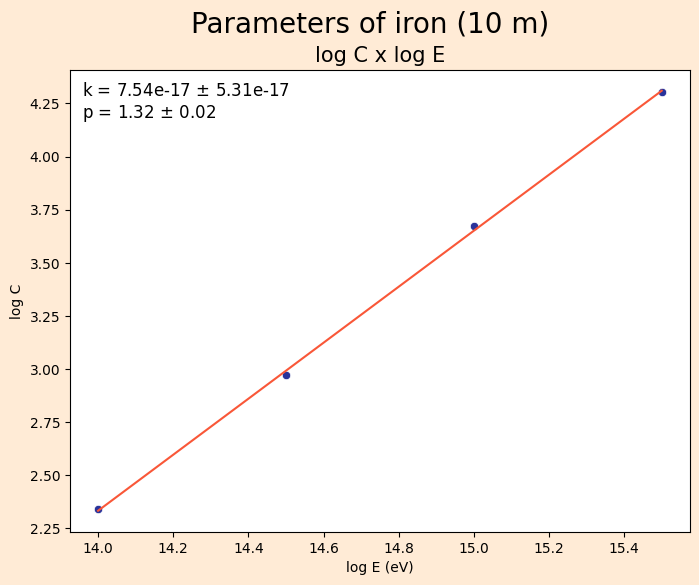

In [399]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [219.1, 932.5, 4712, 2.009e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [400]:
k_iron = coefficients_iron[0] 
p_iron = coefficients_iron[1] 
c_iron = parameters_df['C'] 
#c_photon = df['C_optimized']
E_iron = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_iron)):
    E = (c_iron[i] / k_iron) ** (1 / p_iron)
    E_iron.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_iron,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
2.4587e15,22.193555,7.0132e14
1.4223e15,54.991741,1.7377e15
2.4271e15,23.191905,7.3286e14
7.2944e14,76.916437,2.4306e15
2.3031e15,27.116854,8.5689e14
…,…,…
2.2544e15,28.659457,9.0564e14
2.3708e15,24.975528,7.8923e14
1.8773e15,40.591102,1.2827e15


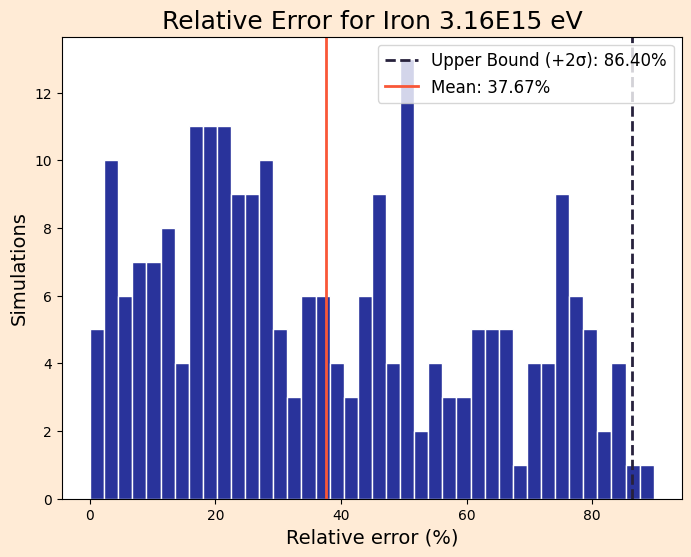

In [401]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

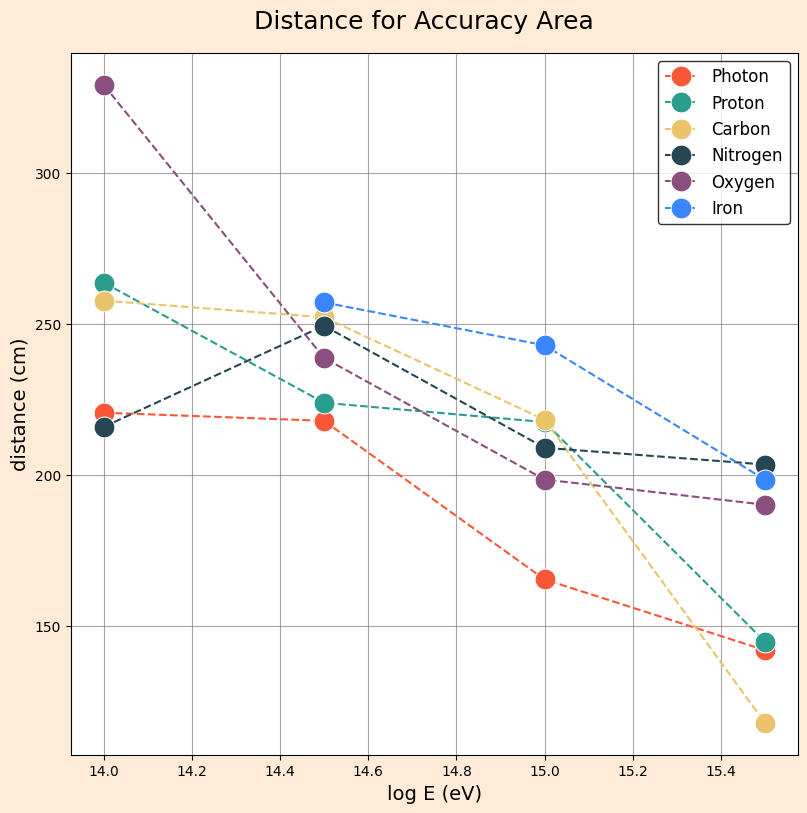

In [425]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [220.53, 217.84, 165.35, 141.94]
proton = [263.57, 223.83, 217.43, 144.77]
carbon = [257.61, 252.13, 218.21, 117.89]
nitrogen = [215.84, 249.32, 208.93, 203.38]
oxygen = [329.04, 238.66, 198.41, 190.07]
iron = [0, 257.03, 242.83, 198.39]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.lineplot(y=photon, x=energy, ax=ax, color='#F95738', marker='o', markersize = 15, linestyle='--', label='Photon')
sns.lineplot(y=proton, x=energy, ax=ax, color='#2A9D8F', marker='o', markersize = 15, linestyle='--', label='Proton')
sns.lineplot(y=carbon, x=energy, ax=ax, color='#E9C46A', marker='o', markersize = 15, linestyle='--', label='Carbon')
sns.lineplot(y=nitrogen, x=energy, ax=ax, color='#264653', marker='o', markersize = 15, linestyle='--', label='Nitrogen')
sns.lineplot(y=oxygen, x=energy, ax=ax, color='#8A4F7D', marker='o', markersize = 15, linestyle='--', label='Oxygen')
sns.lineplot(y=iron[1:], x=energy[1:], ax=ax, color='#3A86FF', marker='o', markersize = 15, linestyle='--', label='Iron')

ax.set_xlabel('log E (eV)', size=14)
ax.set_ylabel('distance (cm)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


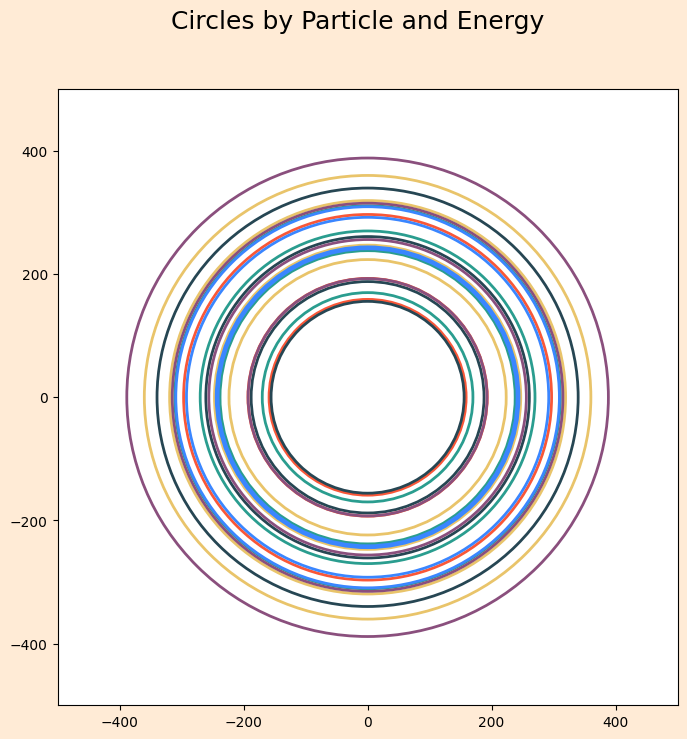

In [404]:
fig, ax = plt.subplots(1,1,figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Circles by Particle and Energy', size=18)

for i, e in enumerate(energy):  
    radius = photon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#F95738', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = proton[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#2A9D8F', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = carbon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#E9C46A', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = nitrogen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#264653', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = oxygen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#8A4F7D', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)


for i, e in enumerate(energy):  
    radius = iron[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#3A86FF', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

plt.xlim([-500,500])
plt.ylim([-500,500])

plt.show()